This code only for recalulate data from 20250221 by refine method for 20250329

In [3]:
# =============================================================================
# Configuration: Define Channel Names (Edit these if channel names change)
# =============================================================================
import os
import re
import gc
import torch
import numpy as np
import tifffile
import pandas as pd
from nd2reader import ND2Reader
from tqdm import tqdm
from cellpose import models
CHANNEL_DAPI  = '40x 405'   # Used for cell mask generation
CHANNEL_DsRed = '40x 561'
CHANNEL_GFP   = '40x 488'

# code to analysis

In [4]:
# =============================================================================
# Set Up Directories and Run Conversion
# =============================================================================
nd2_dir       = r"A:\_Ongoing\20250221_ActRep_rename"
output_dir    = os.path.join(nd2_dir, "Output")
dapi_tiff_dir = os.path.join(output_dir, "DAPI_TIFF")
dsred_tiff_dir= os.path.join(output_dir, "DsRed_TIFF")
gfp_tiff_dir  = os.path.join(output_dir, "GFP_TIFF")
mask_dir      = os.path.join(output_dir, "mask_100")

# Create output directories if they don't exist
os.makedirs(output_dir, exist_ok=True)
os.makedirs(dapi_tiff_dir, exist_ok=True)
os.makedirs(dsred_tiff_dir, exist_ok=True)
os.makedirs(gfp_tiff_dir, exist_ok=True)
os.makedirs(mask_dir, exist_ok=True)

In [5]:
# =============================================================================
# Filter out small or too long mask
# =============================================================================
import os
import numpy as np
import tifffile
from skimage.measure import regionprops
from tqdm import tqdm

# -----------------------------
# SET UP DIRECTORIES
# -----------------------------
output_dir = os.path.join(nd2_dir, "Output")
mask_dir = os.path.join(output_dir, "mask_100")  # Original mask folder
new_mask_dir = os.path.join(output_dir, "mask_filtered")  # New folder for filtered masks
os.makedirs(new_mask_dir, exist_ok=True)

# -----------------------------
# FILTER PARAMETERS
# -----------------------------
size_threshold = 2000      # Remove objects with area < 1500 pixels
length_threshold = 180     # Remove objects with major axis length > 180

# -----------------------------
# PROCESS EACH MASK FILE
# -----------------------------
mask_files = [f for f in os.listdir(mask_dir) if f.lower().endswith(('.tif', '.tiff'))]

for mask_file in tqdm(mask_files, desc="Filtering masks"):
    mask_path = os.path.join(mask_dir, mask_file)
    new_mask_path = os.path.join(new_mask_dir, mask_file)
    try:
        # Read the mask image
        mask_img = tifffile.imread(mask_path)
        
        # Create a copy for filtering
        filtered_mask = mask_img.copy()
        
        # Compute properties of each object in the mask
        for region in regionprops(mask_img):
            # Filter out objects that are too small or too elongated
            if region.area < size_threshold or region.major_axis_length > length_threshold:
                filtered_mask[mask_img == region.label] = 0
        
        # Save the filtered mask
        tifffile.imwrite(new_mask_path, filtered_mask.astype(np.uint16))
        print(f"Saved filtered mask: {new_mask_path}")
        
    except Exception as e:
        print(f"Error processing {mask_file}: {e}")


Filtering masks:   0%|          | 6/4800 [00:00<01:26, 55.60it/s]

Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Act_A1_001_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Act_A1_002_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Act_A1_003_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Act_A1_004_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Act_A1_005_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Act_A1_006_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Act_A1_007_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Act_A1_008_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Act_A1_009_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Act_A1_010_mask.tiff
Saved filtered mask:

Filtering masks:   0%|          | 18/4800 [00:00<01:26, 55.43it/s]

Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Act_A1_012_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Act_A1_013_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Act_A1_014_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Act_A1_015_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Act_A1_016_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Act_A1_017_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Act_A1_018_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Act_A1_019_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Act_A1_020_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Act_A1_021_mask.tiff
Saved filtered mask:

Filtering masks:   1%|          | 31/4800 [00:00<01:20, 59.38it/s]

...

Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Rep_D6_069_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Rep_D6_070_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Rep_D6_071_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Rep_D6_072_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Rep_D6_073_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Rep_D6_074_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Rep_D6_075_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Rep_D6_076_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Rep_D6_077_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Rep_D6_078_mask.tiff
Saved filtered mask:

Filtering masks: 100%|█████████▉| 4793/4800 [01:19<00:00, 60.45it/s]

Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Rep_D6_083_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Rep_D6_084_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Rep_D6_085_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Rep_D6_086_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Rep_D6_087_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Rep_D6_088_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Rep_D6_089_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Rep_D6_090_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Rep_D6_091_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Rep_D6_092_mask.tiff
Saved filtered mask:

Filtering masks: 100%|██████████| 4800/4800 [01:19<00:00, 60.16it/s]

Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Rep_D6_094_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Rep_D6_095_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Rep_D6_096_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Rep_D6_097_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Rep_D6_098_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Rep_D6_099_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered\Rep_D6_100_mask.tiff


# cellpose checing visulize

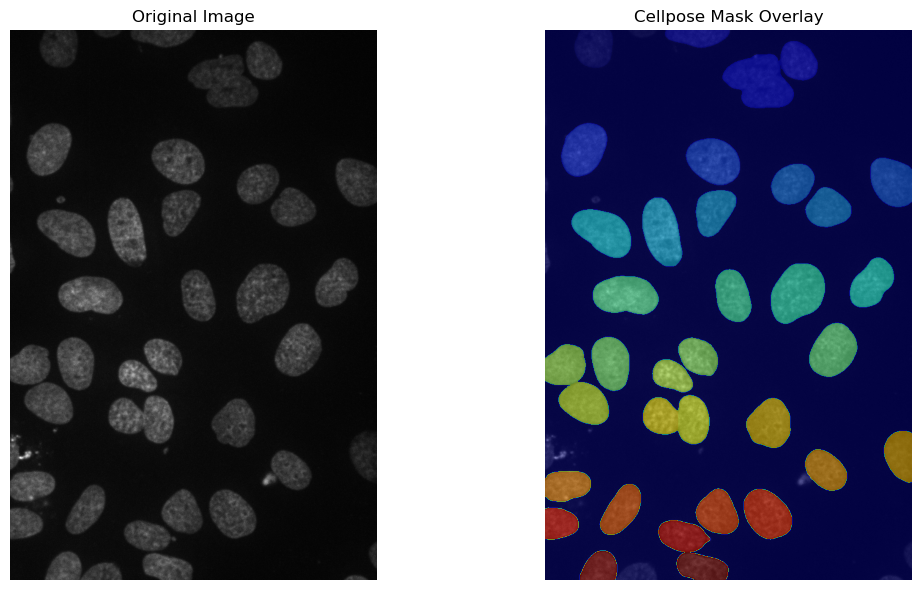

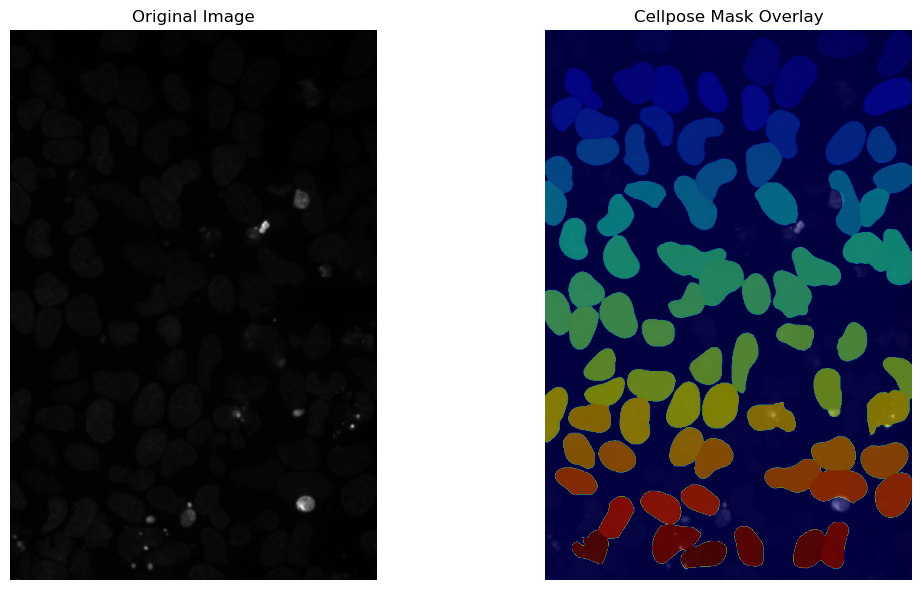

In [8]:
import random
import os
import tifffile
import matplotlib.pyplot as plt
import numpy as np

def visualize_random_samples(image_dir, mask_dir, num_samples=5, seed=None):
    """
    Randomly selects and visualizes TIFF images with their corresponding Cellpose masks.
    
    Parameters:
      image_dir (str): Directory containing the original TIFF images (e.g., DAPI images used for mask generation).
      mask_dir (str): Directory containing the Cellpose mask TIFFs.
      num_samples (int): Number of random samples to visualize.
      seed (int, optional): Seed for reproducibility.
    """
    # Set seed for reproducibility if provided
    if seed is not None:
        random.seed(seed)
    
    # Get list of TIFF files (exclude mask files)
    image_files = [f for f in os.listdir(image_dir) 
                   if f.lower().endswith(('.tiff', '.tif')) and '_mask' not in f]
    
    if not image_files:
        print(f"No TIFF files found in {image_dir}.")
        return
    
    # Adjust number of samples if there are fewer files than requested
    num_samples = min(num_samples, len(image_files))
    samples = random.sample(image_files, num_samples)
    
    for img_file in samples:
        img_path = os.path.join(image_dir, img_file)
        mask_filename = os.path.splitext(img_file)[0] + "_mask.tiff"
        mask_path = os.path.join(mask_dir, mask_filename)
        
        # Check if the corresponding mask file exists
        if not os.path.exists(mask_path):
            print(f"Mask file {mask_filename} does not exist. Skipping {img_file}.")
            continue
        
        try:
            img = tifffile.imread(img_path)
            mask = tifffile.imread(mask_path)
            
            # If the image has multiple channels, average them to get a grayscale representation
            if img.ndim == 3:
                img_display = img.mean(axis=0)
            else:
                img_display = img
            
            # Normalize the image for display purposes
            img_display = img_display.astype(np.float32)
            img_display -= img_display.min()
            if img_display.max() != 0:
                img_display /= img_display.max()
            
            plt.figure(figsize=(12, 6))
            
            # Display the original image
            plt.subplot(1, 2, 1)
            plt.imshow(img_display, cmap='gray')
            plt.title('Original Image')
            plt.axis('off')
            
            # Display the mask overlay on the original image
            plt.subplot(1, 2, 2)
            plt.imshow(img_display, cmap='gray')
            plt.imshow(mask, cmap='jet', alpha=0.5)  # Overlay mask with transparency
            plt.title('Cellpose Mask Overlay')
            plt.axis('off')
            
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f"Error visualizing {img_file}: {e}")

# =============================================================================
# Example Usage
# =============================================================================
# Define the directories for DAPI images (used for mask generation) and the generated masks.
dapi_image_dir = os.path.join(output_dir, "DAPI_TIFF")
mask_output_dir =  os.path.join(output_dir, "mask_filtered")

# Visualize random samples (e.g., 2 samples, with a seed for reproducibility)
visualize_random_samples(dapi_image_dir, mask_output_dir, num_samples=2, seed=332233)


# autosclae the tiff image for better screen show

In [10]:
import os
import numpy as np
import tifffile
from tqdm import tqdm

def autoscale_to_8bit(image, percentile=99):
    """
    Autoscale a 16-bit image to 8-bit using the 99th percentile as the maximum.
    
    Parameters:
      image (np.ndarray): The input image (assumed to be 16-bit).
      percentile (float): The percentile to use for the maximum intensity.
      
    Returns:
      np.ndarray: The rescaled 8-bit image.
    """
    # Compute the minimum and the desired maximum (99th percentile)
    img_min = np.min(image)
    img_p99 = np.percentile(image, percentile)
    
    # Prevent division by zero in case the image is flat
    if img_p99 - img_min == 0:
        scaled = np.zeros_like(image, dtype=np.uint8)
    else:
        # Scale intensities so that values below img_min map to 0 and
        # values at or above img_p99 are capped at 1 (then multiplied by 255).
        scaled = (image - img_min) / (img_p99 - img_min)
        # Clip values above 1 (if any) to 1.
        scaled[scaled > 1] = 1
        scaled = (scaled * 255).astype(np.uint8)
    return scaled

def regenerate_for_viewing(channel_dirs, output_forimage_dir, percentile=99):
    """
    Processes images from each channel directory by autoscaling them from 16-bit to 8-bit,
    using the given percentile as the maximum intensity. The processed images are saved
    in subdirectories under the output_forimage_dir.
    
    Parameters:
      channel_dirs (dict): Dictionary with keys as channel names (e.g., 'DAPI', 'GFP', 'DsRed')
                           and values as the directories containing the original 16-bit images.
      output_forimage_dir (str): Path to the output "forimage" folder.
      percentile (float): Percentile to use for scaling (default is 99).
    """
    # Create the output forimage directory if it doesn't exist.
    os.makedirs(output_forimage_dir, exist_ok=True)
    
    for channel, input_dir in channel_dirs.items():
        # Create a subfolder for the channel
        channel_out_dir = os.path.join(output_forimage_dir, channel)
        os.makedirs(channel_out_dir, exist_ok=True)
        
        # List TIFF files in the input directory (ignore any mask files)
        image_files = [f for f in os.listdir(input_dir)
                       if f.lower().endswith(('.tiff', '.tif')) and '_mask' not in f]
        
        for img_file in tqdm(image_files, desc=f"Processing {channel} images"):
            input_path = os.path.join(input_dir, img_file)
            output_path = os.path.join(channel_out_dir, img_file)
            try:
                img = tifffile.imread(input_path)
                
                # If the image is 3D (e.g., a z-stack), average over the first axis to obtain a 2D image.
                if img.ndim == 3:
                    img = img.mean(axis=0)
                
                # Apply autoscaling to 8-bit.
                scaled_img = autoscale_to_8bit(img, percentile)
                tifffile.imwrite(output_path, scaled_img)
            except Exception as e:
                print(f"Error processing {input_path}: {e}")

# =============================================================================
# Example Usage
# =============================================================================
# Set your output directory (update this path as needed)
output_dir = r"A:\_Ongoing\20250221_ActRep_rename\Output"

# Create the forimage folder under the output directory
output_forimage_dir = os.path.join(output_dir, "forimage")

# Define the directories for each channel (these should be the original 16-bit images)
channel_dirs = {
    "DAPI": dapi_tiff_dir,    # Path to DAPI TIFF images (from your earlier code)
    "GFP": gfp_tiff_dir,      # Path to GFP TIFF images
    "DsRed": dsred_tiff_dir   # Path to DsRed TIFF images
}

# Regenerate the easier-to-view 8-bit images
regenerate_for_viewing(channel_dirs, output_forimage_dir, percentile=99)


Processing DsRed images: 100%|██████████| 4800/4800 [01:06<00:00, 72.64it/s]


# filter out dead cell (use DAPI channel and z-sore)

In [11]:

import os
import numpy as np
import tifffile
from skimage.measure import regionprops
from tqdm import tqdm

def filter_dead_cells_by_dapi(mask_input_dir, dapi_dir, output_mask_dead_dir, z_thresh=3, fraction_thresh=0.1):
    """
    Filters out cell masks that likely represent dead cells based on uneven DAPI intensity.
    
    For each cell region in the mask, the function computes the mean and standard deviation of 
    the DAPI intensities within that region. It then calculates the fraction of pixels whose intensity 
    exceeds (mean + z_thresh * std). If this fraction is above fraction_thresh, the region is removed 
    from the mask.
    
    Parameters:
      mask_input_dir (str): Directory containing the input mask TIFF files (e.g., from previous filtering).
      dapi_dir (str): Directory containing the DAPI channel TIFF images.
      output_mask_dead_dir (str): Directory where the new masks with dead cells filtered out will be saved.
      z_thresh (float): Z-score threshold (default is 3).
      fraction_thresh (float): Fraction threshold for pixels exceeding the z-score threshold (default 0.1, i.e., 10%).
    """
    os.makedirs(output_mask_dead_dir, exist_ok=True)
    
    # List all mask files (TIFF files)
    mask_files = [f for f in os.listdir(mask_input_dir) if f.lower().endswith(('.tif', '.tiff'))]
    
    for mask_file in tqdm(mask_files, desc="Filtering dead cells by DAPI"):
        mask_path = os.path.join(mask_input_dir, mask_file)
        # Assume the corresponding DAPI image has the same base name (without '_mask')
        base_name = os.path.splitext(mask_file)[0].replace('_mask', '')
        dapi_filename = base_name + os.path.splitext(mask_file)[1]
        dapi_path = os.path.join(dapi_dir, dapi_filename)
        
        if not os.path.exists(dapi_path):
            print(f"DAPI image for {mask_file} not found in {dapi_dir}. Skipping.")
            continue
        
        try:
            mask_img = tifffile.imread(mask_path)
            dapi_img = tifffile.imread(dapi_path)
            
            # Copy the mask to modify it
            filtered_mask = mask_img.copy()
            
            # Compute properties for each region in the mask using the DAPI image as the intensity image.
            props = regionprops(mask_img, intensity_image=dapi_img)
            for region in props:
                # Get the intensity values from the DAPI channel for the current cell region.
                coords = region.coords
                cell_intensities = dapi_img[coords[:, 0], coords[:, 1]]
                if cell_intensities.size == 0:
                    continue
                mean_intensity = np.mean(cell_intensities)
                std_intensity = np.std(cell_intensities)
                # Define the threshold as mean + z_thresh * std.
                thresh_value = mean_intensity + z_thresh * std_intensity
                # Compute the fraction of pixels above this threshold.
                fraction = np.sum(cell_intensities > thresh_value) / cell_intensities.size
                
                # If the fraction exceeds the fraction threshold, remove the cell (set pixels to background).
                if fraction > fraction_thresh:
                    filtered_mask[mask_img == region.label] = 0
            
            # Save the new filtered mask.
            output_path = os.path.join(output_mask_dead_dir, mask_file)
            tifffile.imwrite(output_path, filtered_mask.astype(np.uint16))
            print(f"Saved filtered mask: {output_path}")
            
        except Exception as e:
            print(f"Error processing {mask_file}: {e}")

# =============================================================================
# Example Usage:
# =============================================================================
# Update these paths as needed.
output_dir = r"A:\_Ongoing\20250221_ActRep_rename\Output"
mask_input_dir = os.path.join(output_dir, "mask_filtered")      # Input masks (after initial filtering)
dapi_tiff_dir = os.path.join(output_dir, "DAPI_TIFF")             # DAPI channel images
output_mask_dead_dir = os.path.join(output_dir, "mask_filtered_zscore")  # New folder for final masks

# Run the filtering function with a z threshold of 3 and fraction threshold of 0.01 (1%).
filter_dead_cells_by_dapi(mask_input_dir, dapi_tiff_dir, output_mask_dead_dir, z_thresh=3, fraction_thresh=0.01)


Filtering dead cells by DAPI:   0%|          | 18/4800 [00:00<00:55, 86.29it/s]

Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Act_A1_001_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Act_A1_002_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Act_A1_003_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Act_A1_004_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Act_A1_005_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Act_A1_006_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Act_A1_007_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Act_A1_008_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Act_A1_009_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename

Filtering dead cells by DAPI:   1%|          | 27/4800 [00:00<00:56, 85.02it/s]

Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Act_A1_019_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Act_A1_020_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Act_A1_021_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Act_A1_022_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Act_A1_023_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Act_A1_024_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Act_A1_025_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Act_A1_026_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Act_A1_027_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename

Filtering dead cells by DAPI:   1%|          | 46/4800 [00:00<00:53, 88.65it/s]

...

Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Rep_D6_069_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Rep_D6_070_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Rep_D6_071_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Rep_D6_072_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Rep_D6_073_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Rep_D6_074_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Rep_D6_075_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Rep_D6_076_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Rep_D6_077_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename

Filtering dead cells by DAPI: 100%|█████████▉| 4792/4800 [01:10<00:00, 65.34it/s]

Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Rep_D6_084_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Rep_D6_085_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Rep_D6_086_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Rep_D6_087_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Rep_D6_088_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Rep_D6_089_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Rep_D6_090_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Rep_D6_091_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Rep_D6_092_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename

Filtering dead cells by DAPI: 100%|██████████| 4800/4800 [01:10<00:00, 68.44it/s]

Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Rep_D6_099_mask.tiff
Saved filtered mask: A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore\Rep_D6_100_mask.tiff


# after autoscle, after dead cell filer, put all channel together

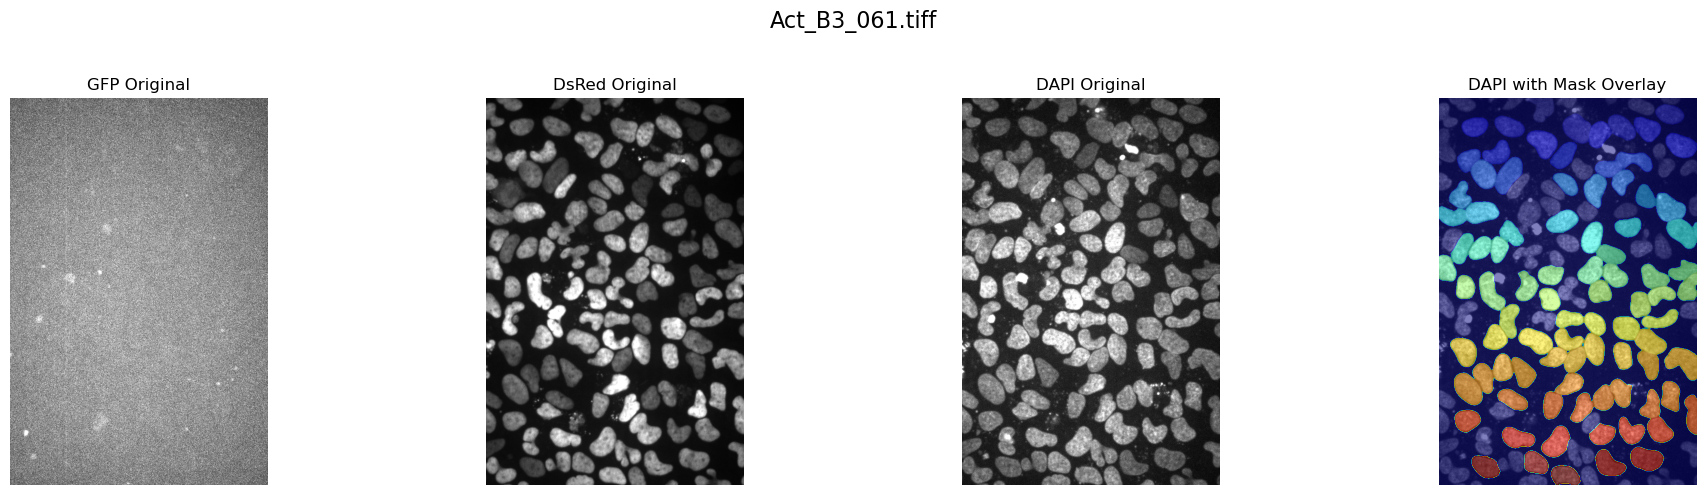

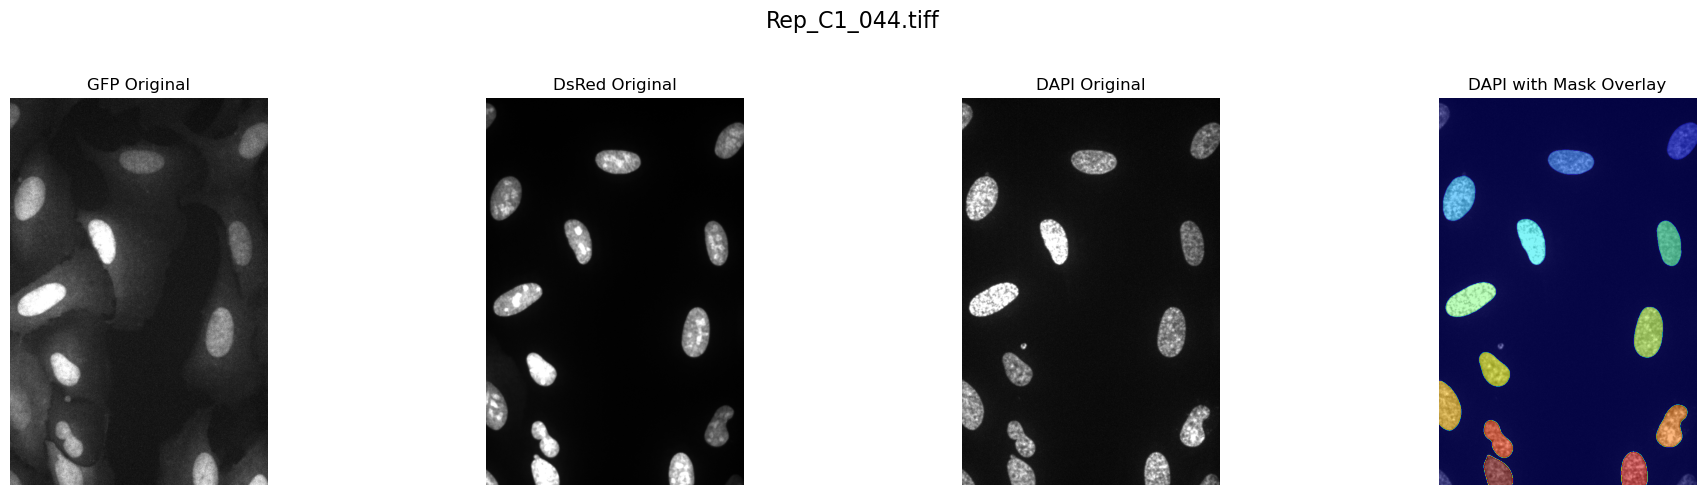

In [17]:
import random
import os
import tifffile
import matplotlib.pyplot as plt
import numpy as np

def visualize_random_samples_all_channels(gfp_dir, dsred_dir, dapi_dir, mask_dir, num_samples=5, seed=None):
    """
    Randomly selects and visualizes TIFF images for three channels along with a mask overlay.
    
    The layout is as follows (left to right):
      - GFP original
      - DsRed original
      - DAPI original
      - DAPI with mask overlay
    
    Parameters:
      gfp_dir (str): Directory containing the GFP channel TIFF images.
      dsred_dir (str): Directory containing the DsRed channel TIFF images.
      dapi_dir (str): Directory containing the DAPI channel TIFF images.
      mask_dir (str): Directory containing the DAPI mask TIFFs.
      num_samples (int): Number of random samples to visualize.
      seed (int, optional): Seed for reproducibility.
    """
    # Use the DAPI channel as reference for file names
    image_files = [f for f in os.listdir(dapi_dir) 
                   if f.lower().endswith(('.tiff', '.tif')) and '_mask' not in f]
    
    if not image_files:
        print(f"No TIFF files found in {dapi_dir}.")
        return
    
    if seed is not None:
        random.seed(seed)
    num_samples = min(num_samples, len(image_files))
    samples = random.sample(image_files, num_samples)
    
    for img_file in samples:
        base_name = os.path.splitext(img_file)[0]
        mask_filename = base_name + "_mask.tiff"
        mask_path = os.path.join(mask_dir, mask_filename)
        
        if not os.path.exists(mask_path):
            print(f"Mask file {mask_filename} does not exist. Skipping {img_file}.")
            continue
        
        try:
            # Build file paths for each channel
            gfp_path = os.path.join(gfp_dir, img_file)
            dsred_path = os.path.join(dsred_dir, img_file)
            dapi_path = os.path.join(dapi_dir, img_file)
            
            # Check if all required files exist
            if not (os.path.exists(gfp_path) and os.path.exists(dsred_path) and os.path.exists(dapi_path)):
                print(f"One or more channel images missing for {img_file}. Skipping.")
                continue
            
            # Load images and mask
            gfp_img = tifffile.imread(gfp_path)
            dsred_img = tifffile.imread(dsred_path)
            dapi_img = tifffile.imread(dapi_path)
            mask = tifffile.imread(mask_path)
            
            # Function to normalize image for display
            def normalize_image(img):
                if img.ndim == 3:
                    img_disp = img.mean(axis=0)
                else:
                    img_disp = img
                img_disp = img_disp.astype(np.float32)
                img_disp -= img_disp.min()
                if img_disp.max() != 0:
                    img_disp /= img_disp.max()
                return img_disp
            
            gfp_disp = normalize_image(gfp_img)
            dsred_disp = normalize_image(dsred_img)
            dapi_disp = normalize_image(dapi_img)
            
            # Create a figure with 4 subplots
            plt.figure(figsize=(20, 5))
            plt.suptitle(img_file, fontsize=16)
            
            # Panel 1: GFP original
            ax1 = plt.subplot(1, 4, 1)
            ax1.imshow(gfp_disp, cmap='gray')
            ax1.set_title('GFP Original')
            ax1.axis('off')
            
            # Panel 2: DsRed original
            ax2 = plt.subplot(1, 4, 2)
            ax2.imshow(dsred_disp, cmap='gray')
            ax2.set_title('DsRed Original')
            ax2.axis('off')
            
            # Panel 3: DAPI original
            ax3 = plt.subplot(1, 4, 3)
            ax3.imshow(dapi_disp, cmap='gray')
            ax3.set_title('DAPI Original')
            ax3.axis('off')
            
            # Panel 4: DAPI with mask overlay
            ax4 = plt.subplot(1, 4, 4)
            ax4.imshow(dapi_disp, cmap='gray')
            ax4.imshow(mask, cmap='jet', alpha=0.5)  # Overlay the mask
            ax4.set_title('DAPI with Mask Overlay')
            ax4.axis('off')
            
            plt.tight_layout(rect=[0, 0, 1, 0.95])
            plt.show()
            
        except Exception as e:
            print(f"Error visualizing {img_file}: {e}")

# =============================================================================
# Example Usage
# =============================================================================
# Define directories for each channel (update these paths as needed)

gfp_tiff_dir = r"A:\_Ongoing\20250221_ActRep_rename\Output\forimage\GFP"
dsred_tiff_dir = r"A:\_Ongoing\20250221_ActRep_rename\Output\forimage\DsRed"
dapi_tiff_dir = r"A:\_Ongoing\20250221_ActRep_rename\Output\forimage\DAPI"
mask_output_dir = r"A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore"

# Visualize random samples (e.g., 2 samples, with a seed for reproducibility)
visualize_random_samples_all_channels(gfp_tiff_dir, dsred_tiff_dir, dapi_tiff_dir, mask_output_dir, num_samples=2, seed=3332)



# collect the min intensity from each image and collect net instensity of GFP and DsRed (including area calculation)

In [14]:
import os
import numpy as np
import pandas as pd
import tifffile
from tqdm import tqdm

# =============================================================================
# Extraction Function for the Updated Naming Strategy
# =============================================================================
def extract_info_from_filename_new(filename):
    """
    Extracts group, sample code, and repeat information from a filename following the pattern:
      "Group_Sample_Repeat.ext"
    For example, "Act_A2_008.tiff" yields:
      Group: "Act"
      Sample: "A2"
      Repeat: "008"
    
    Returns:
      A tuple: (Group, Sample, Repeat)
    """
    base = os.path.splitext(filename)[0]
    parts = base.split('_')
    if len(parts) < 3:
        return "Unknown", "Unknown", "Unknown"
    group = parts[0]
    sample_code = parts[1]
    repeat = parts[2]
    return group, sample_code, repeat

# =============================================================================
# Sample Mapping Dictionary (New Naming Strategy)
# =============================================================================
sample_mapping = {
    "A1": "Tile 1",
    "A2": "Tile 2",
    "A3": "Tile 3",
    "A4": "Tile 4",
    "A5": "Tile 5",
    "A6": "Tile 6",
    "B1": "Tile 7",
    "B2": "Tile 8",
    "B3": "Tile 9",
    "B4": "Tile 10",
    "B5": "Tile 11",
    "B6": "Tile 12",
    "C1": "Tile 13",
    "C2": "Tile 14",
    "C3": "LAP*IDR",
    "C4": "LAPIDR",
    "C5": "LIPIDR",
    "C6": "FL",
    "D1": "optLAP*IDR",
    "D2": "Halo_NLS",
    "D3": "AR_RUNX2",
    "D4": "Tile1woNLS",
    "D5": "RUNX2CTD",
    "D6": "VP16"
}

# =============================================================================
# Function: Create Excel Summary from TIFF and Mask Data
# with Background Correction and Both Net Intensity Calculations
# =============================================================================
def create_excel_from_tiff_and_mask_new(dsred_tiff_dir, gfp_tiff_dir, mask_dir, output_excel):
    """
    Processes DsRed TIFF files (with corresponding GFP and mask files) to calculate cell-level intensities.
    For each cell (as determined by the mask), the function computes:
      - The average GFP and DsRed intensities over the cell region.
      - The minimal intensity (background) from the whole image, per channel.
      - The cell area (number of pixels in the cell mask).
      - The net intensity for each channel, calculated as:
            Net intensity = (cell's average intensity - image minimum intensity)
      - The product of the cell area and the net intensity for each channel, calculated as:
            Net_Intensity_Area = cell_area * (cell's average intensity - image minimum intensity)
    
    The filename is assumed to follow the pattern "Group_Sample_Repeat.ext" (e.g., "Act_A2_008.tiff").
    Group, Sample, and Repeat are extracted using the extraction function.
    A descriptive sample name is added via the sample_mapping dictionary.
    
    The resulting summary is saved as an Excel file.
    """
    # List DsRed TIFF files (excluding any files with "_mask" in the name).
    dsred_files = [f for f in os.listdir(dsred_tiff_dir)
                   if f.lower().endswith(('.tif', '.tiff')) and "_mask" not in f]
    
    if not dsred_files:
        print("No DsRed TIFF files found in", dsred_tiff_dir)
        return
    
    data = []
    for tiff_file in tqdm(dsred_files, desc="Processing TIFF files"):
        dsred_path = os.path.join(dsred_tiff_dir, tiff_file)
        gfp_path = os.path.join(gfp_tiff_dir, tiff_file)
        mask_filename = os.path.splitext(tiff_file)[0] + "_mask.tiff"
        mask_path = os.path.join(mask_dir, mask_filename)
        
        # Verify that the corresponding GFP and mask files exist.
        if not os.path.exists(gfp_path):
            print(f"GFP file not found for {tiff_file}, skipping.")
            continue
        if not os.path.exists(mask_path):
            print(f"Mask file not found for {tiff_file}, skipping.")
            continue
        
        try:
            dsred_img = tifffile.imread(dsred_path)
            gfp_img = tifffile.imread(gfp_path)
            mask_img = tifffile.imread(mask_path)
        except Exception as e:
            print(f"Error reading files for {tiff_file}: {e}")
            continue
        
        # Compute the minimal intensity (background) for the whole image for both channels.
        gfp_min = np.min(gfp_img)
        dsred_min = np.min(dsred_img)
        
        # Identify unique cell labels (ignore background label 0).
        cell_indices = np.unique(mask_img)
        cell_indices = cell_indices[cell_indices != 0]
        
        # Process each cell region.
        for cell in cell_indices:
            cell_mask = (mask_img == cell)
            cell_area = np.sum(cell_mask)  # Number of pixels in the cell.
            avg_gfp = np.mean(gfp_img[cell_mask])
            avg_dsred = np.mean(dsred_img[cell_mask])
            
            # Calculate net intensity per cell (background-corrected average).
            gfp_net = avg_gfp - gfp_min
            dsred_net = avg_dsred - dsred_min
            
            # Calculate net intensity multiplied by cell area.
            gfp_net_area = cell_area * gfp_net
            dsred_net_area = cell_area * dsred_net
            
            record = {
                "File Name": tiff_file,
                "Mask Index": cell,
                "GFP_Mean": avg_gfp,
                "DsRed_Mean": avg_dsred,
                "GFP_Min": gfp_min,
                "DsRed_Min": dsred_min,
                "Cell_Area": cell_area,
                "GFP_Net": gfp_net,
                "DsRed_Net": dsred_net,
                "GFP_Net_Area": gfp_net_area,
                "DsRed_Net_Area": dsred_net_area
            }
            data.append(record)
    
    # Create a DataFrame from the collected records.
    df = pd.DataFrame(data)
    
    # Extract metadata (Group, Sample, Repeat) from the file name.
    df[['Group', 'Sample', 'Repeat']] = df['File Name'].apply(lambda x: pd.Series(extract_info_from_filename_new(x)))
    
    # Map sample codes to descriptive sample names.
    df["Sample_name"] = df["Sample"].map(sample_mapping)
    
    # Rearrange columns.
    df = df[['Group', 'Sample', 'Sample_name', 'Repeat', 'Mask Index',
             'GFP_Mean', 'DsRed_Mean', 'GFP_Min', 'DsRed_Min', 'Cell_Area',
             'GFP_Net', 'DsRed_Net', 'GFP_Net_Area', 'DsRed_Net_Area']]
    
    # Save the summary to an Excel file.
    df.to_excel(output_excel, index=False)
    print("Excel summary saved to:", output_excel)

# =============================================================================
# Example Usage
# =============================================================================
# Adjust these paths as needed.
dsred_tiff_dir = r"A:\_Ongoing\20250221_ActRep_rename\Output\DsRed_TIFF"
gfp_tiff_dir   = r"A:\_Ongoing\20250221_ActRep_rename\Output\GFP_TIFF"
mask_dir       = r"A:\_Ongoing\20250221_ActRep_rename\Output\mask_filtered_zscore"
output_excel   = r"A:\_Ongoing\20250221_ActRep_rename\Output\summary_net_area.xlsx"

create_excel_from_tiff_and_mask_new(dsred_tiff_dir, gfp_tiff_dir, mask_dir, output_excel)


Processing TIFF files: 100%|██████████| 4800/4800 [03:10<00:00, 25.16it/s]


Excel summary saved to: A:\_Ongoing\20250221_ActRep_rename\Output\summary_net_area.xlsx


# area in consider (sum)

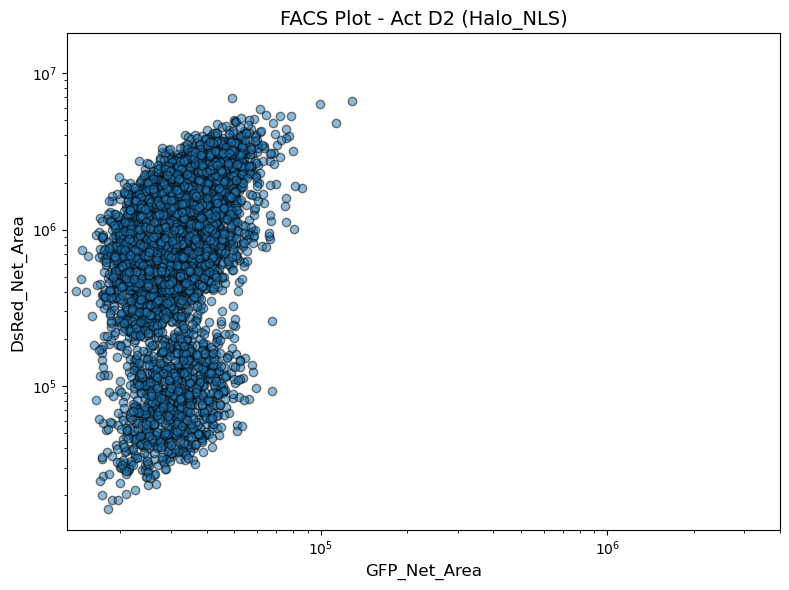

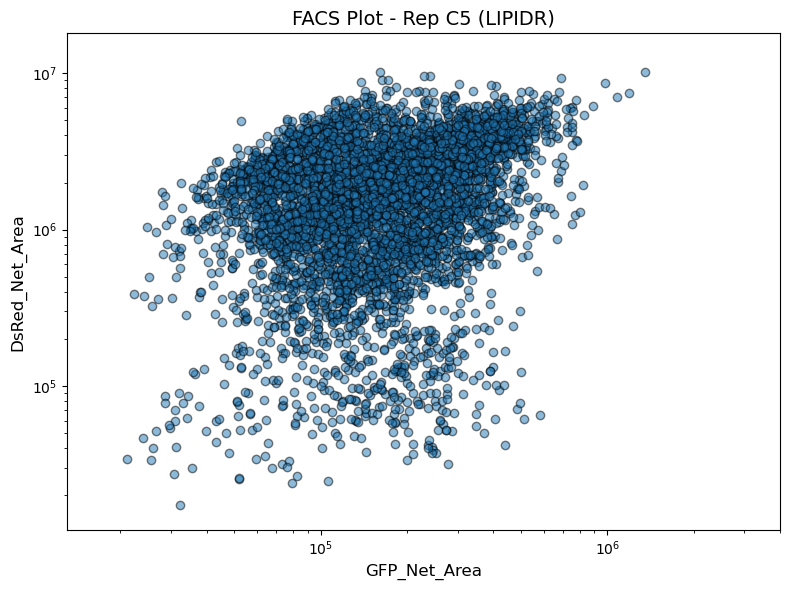

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_facs_sample(df, group, sample_code, x_range=None, y_range=None):
    """
    Plots a FACS-like scatter plot for a specified group and sample.
    
    The x-axis is GFP_Net (log scale) and the y-axis is DsRed_Net (log scale).
    Optionally, you can pass x_range and y_range tuples to manually set the axis limits.
    
    Parameters:
      df (DataFrame): Summary DataFrame containing at least the columns:
                      "Group", "Sample", "GFP_Net", "DsRed_Net", "Sample_name"
      group (str): Group name (e.g., "Act" or "Rep")
      sample_code (str): Sample code (e.g., "A1", "A2")
      x_range (tuple, optional): (xmin, xmax) for the x-axis limits.
      y_range (tuple, optional): (ymin, ymax) for the y-axis limits.
    """
    # Filter data for the specified group and sample.
    df_sample = df[(df["Group"] == group) & (df["Sample"] == sample_code)]
    if df_sample.empty:
        print(f"No data found for {group} {sample_code}.")
        return
    
    # Retrieve a descriptive sample name if available.
    sample_name = df_sample["Sample_name"].iloc[0] if "Sample_name" in df_sample.columns else sample_code
    
    plt.figure(figsize=(8, 6))
    plt.scatter(df_sample["GFP_Net_Area"], df_sample["DsRed_Net_Area"], alpha=0.5, edgecolor='k')
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("GFP_Net_Area", fontsize=12)
    plt.ylabel("DsRed_Net_Area", fontsize=12)
    plt.title(f"FACS Plot - {group} {sample_code} ({sample_name})", fontsize=14)
    
    # Apply custom axis limits if provided.
    if x_range is not None:
        plt.xlim(x_range)
    if y_range is not None:
        plt.ylim(y_range)
    
    plt.grid(False)
    plt.tight_layout()
    plt.show()

# -----------------------------
# Example Usage:
# -----------------------------
# Update the path below as needed.
input_excel = r"A:\_Ongoing\20250221_ActRep_rename\Output\summary_net_area.xlsx"
df = pd.read_excel(input_excel)

# Example: Plot Act group, sample A1.
# You can specify x_range and y_range manually (e.g., (10, 8000)); here, they are left as None.
plot_facs_sample(df, group="Act", sample_code="D2", x_range=(13000, 4000000), y_range=(12000, 18000000))

plot_facs_sample(df, group="Rep", sample_code="C5", x_range=(13000, 4000000), y_range=(12000, 18000000))

In [40]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def plot_facs_sample(df, group, sample_code, x_range=None, y_range=None):
    """
    Plots and returns a FACS-like scatter plot for a specified group and sample.
    
    The x-axis is GFP_Net_Area (log scale) and the y-axis is DsRed_Net_Area (log scale).
    
    Parameters:
      df (DataFrame): Summary DataFrame containing at least the columns:
                      "Group", "Sample", "GFP_Net_Area", "DsRed_Net_Area", "Sample_name"
      group (str): Group name (e.g., "Act" or "Rep")
      sample_code (str): Sample code (e.g., "A1", "A2")
      x_range (tuple, optional): (xmin, xmax) for the x-axis limits.
      y_range (tuple, optional): (ymin, ymax) for the y-axis limits.
    
    Returns:
      fig: The matplotlib figure object.
    """
    # Filter data for the specified group and sample.
    df_sample = df[(df["Group"] == group) & (df["Sample"] == sample_code)]
    if df_sample.empty:
        print(f"No data found for {group} {sample_code}.")
        return None
    
    # Retrieve a descriptive sample name if available.
    sample_name = df_sample["Sample_name"].iloc[0] if "Sample_name" in df_sample.columns else sample_code
    
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(df_sample["GFP_Net_Area"], df_sample["DsRed_Net_Area"], alpha=0.5, edgecolor='k')
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("GFP_Net_Area", fontsize=12)
    ax.set_ylabel("DsRed_Net_Area", fontsize=12)
    ax.set_title(f"FACS Plot - {group} {sample_code} ({sample_name})", fontsize=14)
    
    # Apply custom axis limits if provided.
    if x_range is not None:
        ax.set_xlim(x_range)
    if y_range is not None:
        ax.set_ylim(y_range)
    
    ax.grid(False)
    fig.tight_layout()
    return fig

def save_all_facs_plots(df, save_folder, x_range=None, y_range=None):
    """
    Loops over all unique (Group, Sample) pairs in the DataFrame and saves each FACS plot as a PNG file.
    
    Parameters:
      df (DataFrame): Summary DataFrame containing the relevant columns.
      save_folder (str): Folder path to save the plots.
      x_range (tuple, optional): (xmin, xmax) for the x-axis limits.
      y_range (tuple, optional): (ymin, ymax) for the y-axis limits.
    """
    if not os.path.exists(save_folder):
        os.makedirs(save_folder)
    
    # Get unique combinations of Group and Sample.
    unique_samples = df[['Group', 'Sample']].drop_duplicates()
    
    for index, row in unique_samples.iterrows():
        group = row["Group"]
        sample_code = row["Sample"]
        fig = plot_facs_sample(df, group, sample_code, x_range, y_range)
        if fig is not None:
            # Create a filename such as "Act_A1_facs_plot.png"
            filename = f"{group}_{sample_code}_facs_plot.png"
            save_path = os.path.join(save_folder, filename)
            fig.savefig(save_path)
            plt.close(fig)
            print(f"Saved plot to: {save_path}")

# -----------------------------
# Example Usage:
# -----------------------------
input_excel = r"A:\_Ongoing\20250221_ActRep_rename\Output\summary_net_area.xlsx"
df = pd.read_excel(input_excel)

# Define the folder where you want to save all the FACS plots.
output_plots_folder = r"A:\_Ongoing\20250221_ActRep_rename\FIgure\SUMRAW"

# Optionally, set your custom x and y ranges. For example:
# x_range=(90000, 70000000) and y_range=(60000, 50000000)
# For now, we'll leave them as None so you can manually change them later.
x_range = (13000, 4000000)
y_range = (12000, 18000000)

# Save plots for all unique sample groups.
save_all_facs_plots(df, output_plots_folder, x_range, y_range)


Saved plot to: A:\_Ongoing\20250221_ActRep_rename\FIgure\SUMRAW\Act_A1_facs_plot.png
Saved plot to: A:\_Ongoing\20250221_ActRep_rename\FIgure\SUMRAW\Act_A2_facs_plot.png
Saved plot to: A:\_Ongoing\20250221_ActRep_rename\FIgure\SUMRAW\Act_A3_facs_plot.png
Saved plot to: A:\_Ongoing\20250221_ActRep_rename\FIgure\SUMRAW\Act_A4_facs_plot.png
Saved plot to: A:\_Ongoing\20250221_ActRep_rename\FIgure\SUMRAW\Act_A5_facs_plot.png
Saved plot to: A:\_Ongoing\20250221_ActRep_rename\FIgure\SUMRAW\Act_A6_facs_plot.png
Saved plot to: A:\_Ongoing\20250221_ActRep_rename\FIgure\SUMRAW\Act_B1_facs_plot.png
Saved plot to: A:\_Ongoing\20250221_ActRep_rename\FIgure\SUMRAW\Act_B2_facs_plot.png
Saved plot to: A:\_Ongoing\20250221_ActRep_rename\FIgure\SUMRAW\Act_B3_facs_plot.png
Saved plot to: A:\_Ongoing\20250221_ActRep_rename\FIgure\SUMRAW\Act_B4_facs_plot.png
Saved plot to: A:\_Ongoing\20250221_ActRep_rename\FIgure\SUMRAW\Act_B5_facs_plot.png
Saved plot to: A:\_Ongoing\20250221_ActRep_rename\FIgure\SUMRAW\A

# Compensation matrix (FlowJo)

In [24]:
import pandas as pd
import numpy as np

# -----------------------------
# PARAMETERS & FILE PATHS
# -----------------------------
input_excel = r"A:\_Ongoing\20250221_ActRep_rename\Output\summary_net_area.xlsx"  
output_excel = r"A:\_Ongoing\20250221_ActRep_rename\Output\summary_compensated_matrix.xlsx"  

# -----------------------------
# READ THE DATA
# -----------------------------
df = pd.read_excel(input_excel)

# -----------------------------
# ESTIMATE SPILLOVER FACTOR FROM CONTROL (D6) USING D6 (GFP-only)
# -----------------------------
# We assume that for cells from sample D6, ideally True_DsRed = 0.
# Therefore, any observed DsRed signal in D6 is due to spillover from GFP.
# For each group, we compute:
#     k₂ = median( DsRed_Net_Area / (GFP_Net_Area + ε) )
epsilon = 1e-10
control_df = df[df["Sample"] == "D6"]

# Initialize a dictionary to store k₂ per group.
spillover_factors = {}
for group in control_df["Group"].unique():
    group_ctrl = control_df[control_df["Group"] == group]
    k2 = np.median(group_ctrl["DsRed_Net_Area"] / (group_ctrl["GFP_Net_Area"] + epsilon))
    spillover_factors[group] = k2

print("Computed spillover factors (k₂) per group from D6 control data:")
print(spillover_factors)

# -----------------------------
# APPLY THE COMPENSATION MATRIX
# -----------------------------
# Compensation model:
#   GFP_comp = GFP_Net_Area    (we assume k₁ = 0)
#   DsRed_comp = DsRed_Net_Area − k₂ · GFP_Net_Area
def compensate(row):
    group = row["Group"]
    k2 = spillover_factors.get(group, 0)
    GFP_comp = row["GFP_Net_Area"]
    DsRed_comp = row["DsRed_Net_Area"] - k2 * row["GFP_Net_Area"]
    return pd.Series({"GFP_comp": GFP_comp, "DsRed_comp": DsRed_comp})

df[["GFP_comp", "DsRed_comp"]] = df.apply(compensate, axis=1)

# -----------------------------
# SAVE THE COMPENSATED DATA
# -----------------------------
df.to_excel(output_excel, index=False)
print("Compensated data saved to:", output_excel)



Computed spillover factors (k₂) per group from D6 control data:
{'Act': np.float64(1.4726967837518856), 'Rep': np.float64(0.31131567691832585)}
Compensated data saved to: A:\_Ongoing\20250221_ActRep_rename\Output\summary_compensated_matrix.xlsx


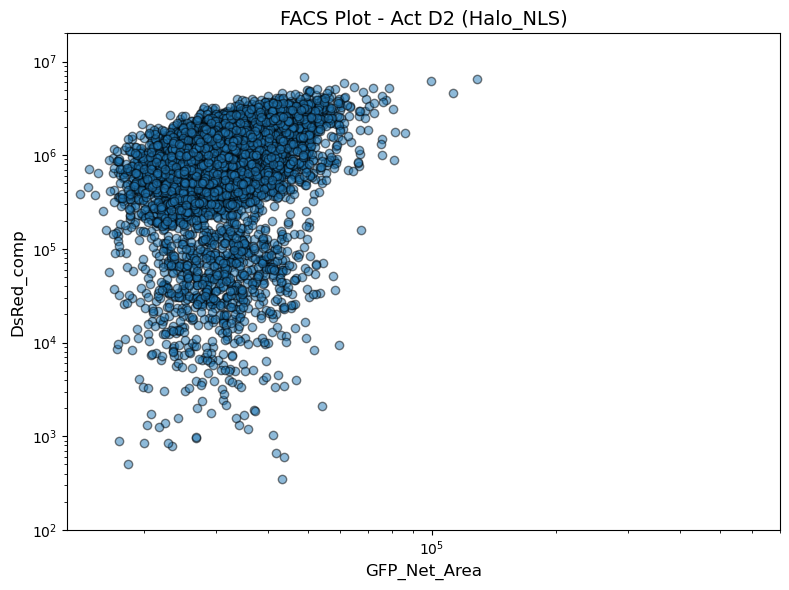

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_facs_sample(df, group, sample_code, x_range=None, y_range=None):
    """
    Plots a FACS-like scatter plot for a specified group and sample.
    
    The x-axis is GFP_Net (log scale) and the y-axis is DsRed_Net (log scale).
    Optionally, you can pass x_range and y_range tuples to manually set the axis limits.
    
    Parameters:
      df (DataFrame): Summary DataFrame containing at least the columns:
                      "Group", "Sample", "GFP_Net", "DsRed_Net", "Sample_name"
      group (str): Group name (e.g., "Act" or "Rep")
      sample_code (str): Sample code (e.g., "A1", "A2")
      x_range (tuple, optional): (xmin, xmax) for the x-axis limits.
      y_range (tuple, optional): (ymin, ymax) for the y-axis limits.
    """
    # Filter data for the specified group and sample.
    df_sample = df[(df["Group"] == group) & (df["Sample"] == sample_code)]
    if df_sample.empty:
        print(f"No data found for {group} {sample_code}.")
        return
    
    # Retrieve a descriptive sample name if available.
    sample_name = df_sample["Sample_name"].iloc[0] if "Sample_name" in df_sample.columns else sample_code
    
    plt.figure(figsize=(8, 6))
    plt.scatter(df_sample["GFP_Net_Area"], df_sample["DsRed_comp"], alpha=0.5, edgecolor='k')
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("GFP_Net_Area", fontsize=12)
    plt.ylabel("DsRed_comp", fontsize=12)
    plt.title(f"FACS Plot - {group} {sample_code} ({sample_name})", fontsize=14)
    
    # Apply custom axis limits if provided.
    if x_range is not None:
        plt.xlim(x_range)
    if y_range is not None:
        plt.ylim(y_range)
    
    plt.grid(False)
    plt.tight_layout()
    plt.show()

# -----------------------------
# Example Usage:
# -----------------------------
# Update the path below as needed.
input_excel = r"A:\_Ongoing\20250221_ActRep_rename\Output\summary_compensated_matrix.xlsx"
df = pd.read_excel(input_excel)

# Example: Plot Act group, sample A1.
# You can specify x_range and y_range manually (e.g., (10, 8000)); here, they are left as None.
plot_facs_sample(df, group="Act", sample_code="D2", x_range=(13000, 700000), y_range=(100,20000000))

In [41]:
# Save all plots
import os
import pandas as pd
import matplotlib.pyplot as plt

def plot_flowjo_sample(df, group, sample_code, x_range=None, y_range=None):
    """
    Creates a FlowJo-style scatter plot for the specified group and sample using the compensated values.
    
    The x-axis displays "GFP_comp" and the y-axis displays "DsRed_comp", both on a log scale.
    
    Parameters:
      df (DataFrame): Summary DataFrame containing at least "Group", "Sample", "Sample_name", 
                      "GFP_comp", and "DsRed_comp".
      group (str): Group name (e.g., "Act" or "Rep").
      sample_code (str): Sample code (e.g., "A1", "A2").
      x_range (tuple, optional): (xmin, xmax) for the x-axis limits.
      y_range (tuple, optional): (ymin, ymax) for the y-axis limits.
    
    Returns:
      fig: The matplotlib Figure object (or None if no data is found).
    """
    # Filter to the desired sample.
    df_sample = df[(df["Group"] == group) & (df["Sample"] == sample_code)]
    if df_sample.empty:
        print(f"No data found for {group} {sample_code}.")
        return None

    # Retrieve a descriptive sample name (if available).
    sample_name = df_sample["Sample_name"].iloc[0] if "Sample_name" in df_sample.columns else sample_code
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Create the scatter plot.
    ax.scatter(df_sample["GFP_comp"], df_sample["DsRed_comp"], alpha=0.5, edgecolor='k')
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("GFP_comp", fontsize=12)
    ax.set_ylabel("DsRed_comp", fontsize=12)
    ax.set_title(f"FlowJo Compensation Plot - {group} {sample_code} ({sample_name})", fontsize=14)
    
    # Apply custom axis limits if given.
    if x_range is not None:
        ax.set_xlim(x_range)
    if y_range is not None:
        ax.set_ylim(y_range)
    
    ax.grid(False)
    fig.tight_layout()
    
    return fig

def save_all_flowjo_plots(df, save_folder, x_range=None, y_range=None):
    """
    Loops over all unique (Group, Sample) pairs in the DataFrame and saves a FlowJo-style scatter plot for each.
    
    Parameters:
      df (DataFrame): The summary DataFrame containing "Group", "Sample", "GFP_comp", "DsRed_comp", etc.
      save_folder (str): Folder path to save the plots.
      x_range (tuple, optional): (xmin, xmax) for the x-axis.
      y_range (tuple, optional): (ymin, ymax) for the y-axis.
    """
    if not os.path.exists(save_folder):
        os.makedirs(save_folder)
    
    # Get unique combinations of Group and Sample.
    unique_samples = df[['Group', 'Sample']].drop_duplicates()
    
    for idx, row in unique_samples.iterrows():
        group = row["Group"]
        sample_code = row["Sample"]
        fig = plot_flowjo_sample(df, group, sample_code, x_range, y_range)
        if fig is not None:
            # Construct a filename like "Act_A1_flowjo_plot.png"
            filename = f"{group}_{sample_code}_flowjo_plot.png"
            filepath = os.path.join(save_folder, filename)
            fig.savefig(filepath)
            plt.close(fig)
            print(f"Saved plot to: {filepath}")

# -----------------------------
# Example Usage:
# -----------------------------
input_excel = r"A:\_Ongoing\20250221_ActRep_rename\Output\summary_compensated_matrix.xlsx"  # Make sure this file contains the compensated columns
df = pd.read_excel(input_excel)

# Define the output folder to save the plots.
output_plots_folder = r"A:\_Ongoing\20250221_ActRep_rename\FIgure\FlowJo_plots"

# Optionally, set custom axis limits (modify these values as needed).
x_limits = (13000, 4000000)  # example: adjust for GFP_comp range on log scale
y_limits = (100, 18000000)   # example: adjust for DsRed_comp range on log scale

# Save all FlowJo-style plots.
save_all_flowjo_plots(df, output_plots_folder, x_range=x_limits, y_range=y_limits)


Saved plot to: A:\_Ongoing\20250221_ActRep_rename\FIgure\FlowJo_plots\Act_A1_flowjo_plot.png
Saved plot to: A:\_Ongoing\20250221_ActRep_rename\FIgure\FlowJo_plots\Act_A2_flowjo_plot.png
Saved plot to: A:\_Ongoing\20250221_ActRep_rename\FIgure\FlowJo_plots\Act_A3_flowjo_plot.png
Saved plot to: A:\_Ongoing\20250221_ActRep_rename\FIgure\FlowJo_plots\Act_A4_flowjo_plot.png
Saved plot to: A:\_Ongoing\20250221_ActRep_rename\FIgure\FlowJo_plots\Act_A5_flowjo_plot.png
Saved plot to: A:\_Ongoing\20250221_ActRep_rename\FIgure\FlowJo_plots\Act_A6_flowjo_plot.png
Saved plot to: A:\_Ongoing\20250221_ActRep_rename\FIgure\FlowJo_plots\Act_B1_flowjo_plot.png
Saved plot to: A:\_Ongoing\20250221_ActRep_rename\FIgure\FlowJo_plots\Act_B2_flowjo_plot.png
Saved plot to: A:\_Ongoing\20250221_ActRep_rename\FIgure\FlowJo_plots\Act_B3_flowjo_plot.png
Saved plot to: A:\_Ongoing\20250221_ActRep_rename\FIgure\FlowJo_plots\Act_B4_flowjo_plot.png
Saved plot to: A:\_Ongoing\20250221_ActRep_rename\FIgure\FlowJo_plots\

# base on Blank sample, filter out untransfected cell and calculate the positive ratio
# D6 is control group

In [45]:
import pandas as pd
import numpy as np

# -----------------------------
# PARAMETERS & FILE PATHS
# -----------------------------
input_excel = r"A:\_Ongoing\20250221_ActRep_rename\Output\summary_compensated_matrix.xlsx"  
output_excel_cells = r"A:\_Ongoing\20250221_ActRep_rename\Output\summary_cells_with_flags.xlsx"
output_excel_summary = r"A:\_Ongoing\20250221_ActRep_rename\Output\summary_thresholds_and_ratio.xlsx"

# -----------------------------
# READ THE DATA
# -----------------------------
df = pd.read_excel(input_excel)

# -----------------------------
# CALCULATE THRESHOLDS FROM CONTROL (D6) FOR EACH GROUP
# -----------------------------
# We assume for control (D6) the following:
# For GFP:
#   - In Act: use the 99.5th percentile (i.e., high values are positive)
#   - In Rep: use the 0.5th percentile (i.e., low values are positive)
# For DsRed:
#   - For both groups: use the 99.5th percentile (i.e., high values are positive)
thresholds = {}
for group in df["Group"].unique():
    ctrl = df[(df["Group"] == group) & (df["Sample"] == "D6")]
    # Consider only positive values
    pos_gfp = ctrl[ctrl["GFP_comp"] > 0]["GFP_comp"]
    pos_dsred = ctrl[ctrl["DsRed_comp"] > 0]["DsRed_comp"]
    if group == "Rep":
        th_gfp = np.percentile(pos_gfp, 0.5) if not pos_gfp.empty else np.nan
    else:
        th_gfp = np.percentile(pos_gfp, 99.5) if not pos_gfp.empty else np.nan
    th_dsred = np.percentile(pos_dsred, 99.5) if not pos_dsred.empty else np.nan
    thresholds[group] = {"GFP": th_gfp, "DsRed": th_dsred}

print("Calculated thresholds per group from D6 control (using adjusted percentiles):")
print(thresholds)

# -----------------------------
# ASSIGN POSITIVITY FLAGS AT THE CELL LEVEL
# -----------------------------
def mark_positive(row):
    group = row["Group"]
    th_gfp = thresholds[group]["GFP"]
    th_dsred = thresholds[group]["DsRed"]
    # For GFP: In Rep, positive if value is less than threshold; in Act, positive if greater.
    if not np.isnan(th_gfp):
        if group == "Rep":
            pos_gfp = row["GFP_comp"] < th_gfp
        else:
            pos_gfp = row["GFP_comp"] > th_gfp
    else:
        pos_gfp = False
    # For DsRed, always positive if above threshold.
    if not np.isnan(th_dsred):
        pos_dsred = row["DsRed_comp"] > th_dsred
    else:
        pos_dsred = False
    return pd.Series({"GFP_Positive": pos_gfp, "DsRed_Positive": pos_dsred})

df[["GFP_Positive", "DsRed_Positive"]] = df.apply(mark_positive, axis=1)

# -----------------------------
# BUILD SAMPLE-LEVEL SUMMARY
# -----------------------------
summary_list = []
unique_samples = df[['Group', 'Sample']].drop_duplicates()

for _, row in unique_samples.iterrows():
    group = row["Group"]
    sample = row["Sample"]
    sample_df = df[(df["Group"] == group) & (df["Sample"] == sample)]
    total = len(sample_df)
    # Count negative cells (where the compensated value is <= 0)
    neg_gfp = np.sum(sample_df["GFP_comp"] <= 0)
    neg_dsred = np.sum(sample_df["DsRed_comp"] <= 0)
    pct_neg_gfp = (neg_gfp / total) * 100 if total > 0 else np.nan
    pct_neg_dsred = (neg_dsred / total) * 100 if total > 0 else np.nan
    
    # For the ratio, we want the fraction of DsRed positive cells that also are GFP positive.
    pos_dsred = sample_df["DsRed_Positive"].sum()
    pos_both = ((sample_df["GFP_Positive"]) & (sample_df["DsRed_Positive"])).sum()
    ratio = (pos_both / pos_dsred * 100) if pos_dsred > 0 else np.nan
    
    summary_list.append({
        "Group": group,
        "Sample": sample,
        "Total_Cells": total,
        "Negative_GFP_%": pct_neg_gfp,
        "Negative_DsRed_%": pct_neg_dsred,
        "DsRed_Positive_Cells": pos_dsred,
        "Both_Positive_Cells": pos_both,
        "Ratio_Both_over_DsRed_%": ratio
    })

df_summary = pd.DataFrame(summary_list)

# -----------------------------
# SAVE THE OUTPUTS TO EXCEL
# -----------------------------
df.to_excel(output_excel_cells, index=False)
print("Cell-level data with positivity flags saved to:", output_excel_cells)

df_summary.to_excel(output_excel_summary, index=False)
print("Sample-level summary saved to:", output_excel_summary)


Calculated thresholds per group from D6 control (using adjusted percentiles):
{'Act': {'GFP': np.float64(61246.264999999956), 'DsRed': np.float64(17910.283296557318)}, 'Rep': {'GFP': np.float64(29041.065000000013), 'DsRed': np.float64(64741.53121098242)}}
Cell-level data with positivity flags saved to: A:\_Ongoing\20250221_ActRep_rename\Output\summary_cells_with_flags.xlsx
Sample-level summary saved to: A:\_Ongoing\20250221_ActRep_rename\Output\summary_thresholds_and_ratio.xlsx


In [46]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def assign_cell_color(row):
    """
    Assign a color based on the positivity flags.
      - Both negative -> "gray"
      - Only DsRed positive -> "red"
      - Only GFP positive -> "green"
      - Both positive -> "purple"
    """
    if (not row["GFP_Positive"]) and (not row["DsRed_Positive"]):
        return "gray"
    elif (not row["GFP_Positive"]) and (row["DsRed_Positive"]):
        return "red"
    elif (row["GFP_Positive"]) and (not row["DsRed_Positive"]):
        return "green"
    elif (row["GFP_Positive"]) and (row["DsRed_Positive"]):
        return "purple"
    else:
        return "black"  # fallback

def plot_sample_with_threshold(df, group, sample_code, threshold_gfp, threshold_dsred, 
                               x_range=None, y_range=None):
    """
    Creates a FACS-style scatter plot for a specific sample from the cell-level summary.
    
    Axes:
      - x-axis: GFP_comp (log scale)
      - y-axis: DsRed_comp (log scale)
      
    Overlays:
      - Vertical line at threshold_gfp
      - Horizontal line at threshold_dsred
      
    Colors:
      - Grey: both negative
      - Red: DsRed positive only
      - Green: GFP positive only
      - Purple: both positive
      
    Also calculates the ratio: (# cells positive for both) / (# cells positive for DsRed) * 100,
    and displays that ratio (in percentage) in the top-right corner of the plot (without any label text).
    
    Parameters:
      df (DataFrame): The summary cell-level DataFrame. It must include the columns:
                      "Group", "Sample", "GFP_comp", "DsRed_comp", "GFP_Positive", "DsRed_Positive",
                      and "Sample_name".
      group (str): Group name (e.g., "Act" or "Rep").
      sample_code (str): Sample code (e.g., "A1").
      threshold_gfp (float): The GFP threshold (vertical line) to draw.
      threshold_dsred (float): The DsRed threshold (horizontal line) to draw.
      x_range (tuple, optional): (xmin, xmax) for the x-axis.
      y_range (tuple, optional): (ymin, ymax) for the y-axis.
      
    Returns:
      fig: The created matplotlib Figure object.
    """
    # Filter data for the specified sample.
    sample_df = df[(df["Group"] == group) & (df["Sample"] == sample_code)]
    if sample_df.empty:
        print(f"No data found for {group} {sample_code}.")
        return None
    
    # Retrieve sample descriptive name if available.
    sample_name = sample_df["Sample_name"].iloc[0] if "Sample_name" in sample_df.columns else sample_code
    
    # Assign color based on positivity.
    sample_df = sample_df.copy()  # avoid modifying original DataFrame
    sample_df["Color"] = sample_df.apply(assign_cell_color, axis=1)
    
    # Calculate the ratio: (# cells positive for both) / (# cells positive for DsRed) * 100.
    num_pos_dsred = sample_df["DsRed_Positive"].sum()
    num_both = ((sample_df["GFP_Positive"]) & (sample_df["DsRed_Positive"])).sum()
    ratio = (num_both / num_pos_dsred * 100) if num_pos_dsred > 0 else np.nan
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Create scatter plot.
    scatter = ax.scatter(sample_df["GFP_comp"], sample_df["DsRed_comp"], 
                         c=sample_df["Color"], alpha=0.6, edgecolor="k", s=40)
    
    # Set log scale.
    ax.set_xscale("log")
    ax.set_yscale("log")
    
    # Set axis limits if provided.
    if x_range is not None:
        ax.set_xlim(x_range)
    if y_range is not None:
        ax.set_ylim(y_range)
    
    ax.set_xlabel("GFP_comp", fontsize=12)
    ax.set_ylabel("DsRed_comp", fontsize=12)
    ax.set_title(f"FACS Plot - {group} {sample_code} ({sample_name})", fontsize=14)
    
    # Draw threshold lines:
    ax.axvline(threshold_gfp, color="black", linestyle="--", linewidth=1)
    ax.axhline(threshold_dsred, color="black", linestyle="--", linewidth=1)
    
    # Place the ratio in the top-right corner using axis coordinates.
    if not np.isnan(ratio):
        ax.text(0.98, 0.98, f"{ratio:.1f}%", transform=ax.transAxes, 
                horizontalalignment="right", verticalalignment="top", fontsize=12)
    
    ax.grid(False)
    plt.tight_layout()
    
    return fig

def save_all_sample_plots(df, save_folder, threshold_dict, x_range=None, y_range=None):
    """
    Loops through all unique (Group, Sample) pairs in df and saves each FACS-style plot as a PNG.
    
    Parameters:
      df (DataFrame): The cell-level summary DataFrame.
      save_folder (str): Directory in which to save the plots.
      threshold_dict (dict): A dictionary with group keys containing a dictionary with keys 
                             "GFP" and "DsRed" for the threshold values.
                             For example: {"Act": {"GFP": val1, "DsRed": val2}, ...}
      x_range (tuple, optional): x-axis limits.
      y_range (tuple, optional): y-axis limits.
    """
    if not os.path.exists(save_folder):
        os.makedirs(save_folder)
    
    unique_samples = df[['Group', 'Sample']].drop_duplicates()
    for _, row in unique_samples.iterrows():
        group = row["Group"]
        sample = row["Sample"]
        thresh_gfp = threshold_dict.get(group, {}).get("GFP", None)
        thresh_dsred = threshold_dict.get(group, {}).get("DsRed", None)
        fig = plot_sample_with_threshold(df, group, sample, thresh_gfp, thresh_dsred, x_range, y_range)
        if fig is not None:
            filename = f"{group}_{sample}_facs.png"
            filepath = os.path.join(save_folder, filename)
            fig.savefig(filepath)
            plt.close(fig)
            print(f"Saved plot: {filepath}")

# -----------------------------
# Example Usage:
# -----------------------------
# Load the cell-level data that includes positivity flags.
input_cells_excel = r"A:\_Ongoing\20250221_ActRep_rename\Output\summary_cells_with_flags.xlsx"
df_cells = pd.read_excel(input_cells_excel)

# Define thresholds (these should be determined from your D6 control in each group, 
# using the 99.5th percentile on the positive values, for example).
# For this example, we'll provide some dummy numbers; adjust them as needed.
# For instance, assume for group Act: GFP threshold = 20000, DsRed threshold = 15000
# and for group Rep: GFP threshold = 50000, DsRed threshold = 40000.
thresholds = {
    "Act": {"GFP": 61246.264999999956, "DsRed": 17910.283296557318},
    "Rep": {"GFP": 29041.065000000013, "DsRed": 64741.53121098242}
}

# Optionally, you can set custom x_range and y_range (on log scale) for the plots.
x_limits = (13000, 4000000)
y_limits = (100, 18000000)

# Define folder to save the plots.
output_plots_folder = r"A:\_Ongoing\20250221_ActRep_rename\FIgure\FACS_flag_plots"

# Save plots for all unique samples.
save_all_sample_plots(df_cells, output_plots_folder, thresholds, x_range=x_limits, y_range=y_limits)


Saved plot: A:\_Ongoing\20250221_ActRep_rename\FIgure\FACS_flag_plots\Act_A1_facs.png
Saved plot: A:\_Ongoing\20250221_ActRep_rename\FIgure\FACS_flag_plots\Act_A2_facs.png
Saved plot: A:\_Ongoing\20250221_ActRep_rename\FIgure\FACS_flag_plots\Act_A3_facs.png
Saved plot: A:\_Ongoing\20250221_ActRep_rename\FIgure\FACS_flag_plots\Act_A4_facs.png
Saved plot: A:\_Ongoing\20250221_ActRep_rename\FIgure\FACS_flag_plots\Act_A5_facs.png
Saved plot: A:\_Ongoing\20250221_ActRep_rename\FIgure\FACS_flag_plots\Act_A6_facs.png
Saved plot: A:\_Ongoing\20250221_ActRep_rename\FIgure\FACS_flag_plots\Act_B1_facs.png
Saved plot: A:\_Ongoing\20250221_ActRep_rename\FIgure\FACS_flag_plots\Act_B2_facs.png
Saved plot: A:\_Ongoing\20250221_ActRep_rename\FIgure\FACS_flag_plots\Act_B3_facs.png
Saved plot: A:\_Ongoing\20250221_ActRep_rename\FIgure\FACS_flag_plots\Act_B4_facs.png
Saved plot: A:\_Ongoing\20250221_ActRep_rename\FIgure\FACS_flag_plots\Act_B5_facs.png
Saved plot: A:\_Ongoing\20250221_ActRep_rename\FIgure\

# only consider DsRed Positive and make box plots

In [49]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Sample mapping dictionary (should be defined as in your data)
sample_mapping = {
    "A1": "Tile 1",
    "A2": "Tile 2",
    "A3": "Tile 3",
    "A4": "Tile 4",
    "A5": "Tile 5",
    "A6": "Tile 6",
    "B1": "Tile 7",
    "B2": "Tile 8",
    "B3": "Tile 9",
    "B4": "Tile 10",
    "B5": "Tile 11",
    "B6": "Tile 12",
    "C1": "Tile 13",
    "C2": "Tile 14",
    "C3": "LAP*IDR",
    "C4": "LAPIDR",
    "C5": "LIPIDR",
    "C6": "FL",
    "D1": "optLAP*IDR",
    "D2": "Halo_NLS",
    "D3": "AR_RUNX2",
    "D4": "Tile1woNLS",
    "D5": "RUNX2CTD",
    "D6": "VP16"
}

def natural_sort_key(s):
    """
    Returns a tuple for natural sorting of strings like 'A1', 'A2', 'D5'.
    """
    m = re.match(r"([A-Za-z]+)(\d+)", s)
    if m:
        return (m.group(1), int(m.group(2)))
    else:
        return (s, 0)

def create_boxplot_for_group(df, group, x_limits, save_path):
    """
    Creates and saves a vertical (stacked) box plot for one group (e.g., "Act" or "Rep").
    
    The data are filtered to only include DsRed positive cells. The plot uses "GFP_comp" on the 
    x-axis (log scale) and shows a box plot for each sample (ordered naturally by the sample code), 
    with the y-tick labels replaced by the descriptive names from sample_mapping.
    
    Parameters:
      df (DataFrame): The cell-level data, which must contain the following columns:
                      "Group", "Sample", "GFP_comp", "DsRed_comp", "DsRed_Positive", and "Sample_name" (optional)
      group (str): The group to plot (e.g., "Act" or "Rep").
      x_limits (tuple): (xmin, xmax) for the x-axis in the box plot.
      save_path (str): The file path (including filename) to save the plot.
    """
    # Filter to the specified group and only DsRed positive cells.
    df_group = df[(df["Group"] == group) & (df["DsRed_Positive"] == True)]
    
    if df_group.empty:
        print(f"No data for group {group} with DsRed positive cells.")
        return

    # Determine the unique sample codes in natural order.
    sample_codes = sorted(df_group["Sample"].unique(), key=natural_sort_key)
    
    # Create a new column for the sample labels based on sample_mapping.
    # If the "Sample_name" column exists and is valid, you can use that. Otherwise, map using sample_mapping.
    df_group["Sample_Label"] = df_group["Sample"].map(lambda s: sample_mapping.get(s, s))
    
    # Create the box plot. We'll plot GFP_comp (x-axis) vs. Sample (y-axis, categorical)
    fig, ax = plt.subplots(figsize=(8, len(sample_codes) * 0.6 + 2))
    
    # Use seaborn's boxplot; set order by sample code so they stack in order.
    sns.boxplot(x="GFP_comp", y="Sample", data=df_group, order=sample_codes, ax=ax,
                orient="h", color="skyblue", fliersize=3)
    
    # Set x-axis to log scale.
    ax.set_xscale("log")
    ax.set_xlim(x_limits)
    
    ax.set_xlabel("GFP_comp (log scale)", fontsize=12)
    ax.set_ylabel("")  # We'll replace y labels
    
    # Replace y-axis tick labels with descriptive names.
    # The ticks are in the same order as sample_codes.
    new_labels = [sample_mapping.get(s, s) for s in sample_codes]
    ax.set_yticklabels(new_labels, fontsize=10)
    
    ax.set_title(f"Box Plot of GFP_comp (DsRed Positive) - {group} Group", fontsize=14)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close(fig)
    print(f"Saved box plot for group {group} to {save_path}")

# -----------------------------
# Main Code to Loop Over Groups and Save Plots
# -----------------------------
input_cells_excel = r"A:\_Ongoing\20250221_ActRep_rename\Output\summary_cells_with_flags.xlsx"
df_cells = pd.read_excel(input_cells_excel)

# Set the x-axis limits for the box plot as provided.
x_limits = (13000, 4000000)

# Define the output folder for the plots.
output_folder = r"a:\_Ongoing\20250221_ActRep_rename\FIgure"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# For each group of interest (e.g. Act and Rep), create and save the plot.
for grp in df_cells["Group"].unique():
    save_path = os.path.join(output_folder, f"{grp}_GFP_comp_BoxPlot.png")
    create_boxplot_for_group(df_cells, grp, x_limits, save_path)


C:\Users\NongyunWang\AppData\Local\Temp\ipykernel_27080\380754371.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_group["Sample_Label"] = df_group["Sample"].map(lambda s: sample_mapping.get(s, s))
C:\Users\NongyunWang\AppData\Local\Temp\ipykernel_27080\380754371.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(new_labels, fontsize=10)
C:\Users\NongyunWang\AppData\Local\Temp\ipykernel_27080\380754371.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

Saved box plot for group Act to a:\_Ongoing\20250221_ActRep_rename\FIgure\Act_GFP_comp_BoxPlot.png


C:\Users\NongyunWang\AppData\Local\Temp\ipykernel_27080\380754371.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(new_labels, fontsize=10)


Saved box plot for group Rep to a:\_Ongoing\20250221_ActRep_rename\FIgure\Rep_GFP_comp_BoxPlot.png
